In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import seaborn as sns

In [6]:
#Load the iris dataset
df =sns.load_dataset("iris")

In [7]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [8]:
df.shape # rows and columns

(150, 5)

In [9]:
# basic data exploration
print("\nBasic Infromation about Dataset:")
print(df.info()) # overview of dataset


Basic Infromation about Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [11]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(1)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

<Figure size 1200x800 with 0 Axes>

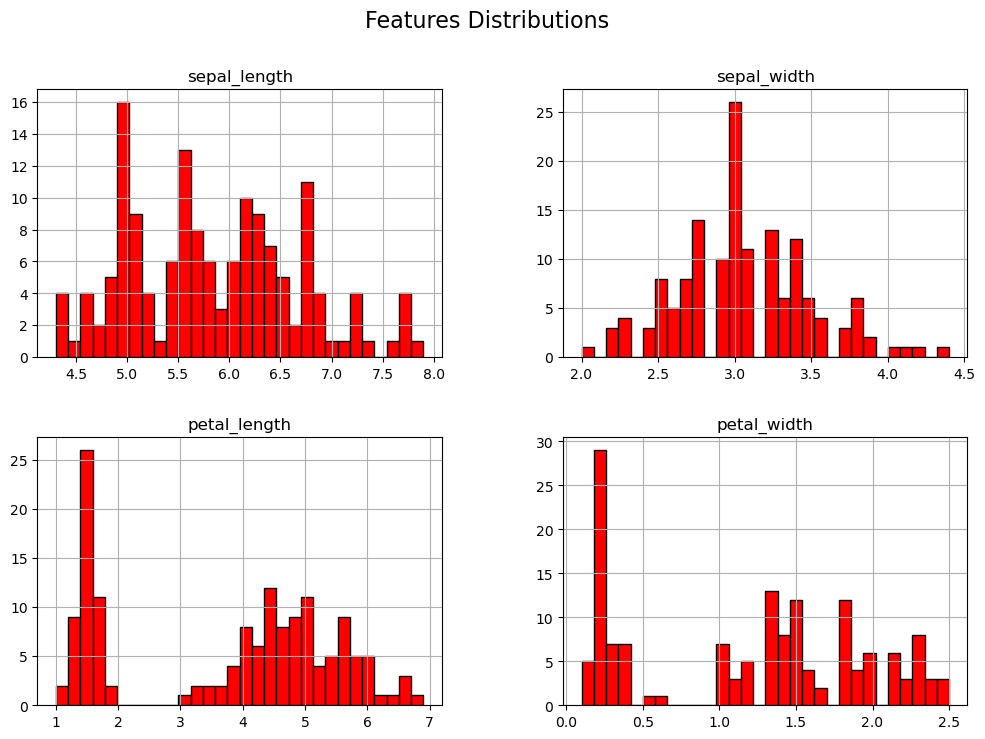

In [24]:
# Histogram for distribution of features
plt.figure(figsize=(12,8))
df.hist(figsize=(12,8),bins=30,color='r',edgecolor='black')
plt.suptitle("Features Distributions",fontsize=16)
plt.show()

###<b> inference from Histogram:</b>
1. **Sepal Length**:
- The distribution of sepal length appers to be roughly normal with a slight skew toward thr right.
- Most of the sepal lenghts fall between 4.5 and 7.5cm.

2.**Sepal Width**:
   - The distribution of sepal width is also roughly normal but with a slight skew towards the left.
   - Most of the sepal widths fall between 2.5 and 3.5 cm,
   
3.**Petal Lenght**:
   - The distribution of petal lenght is more spread out and shows a clear separation between different species
   - There are distinct peaks incicating the presence of different species with Varying petal lengths.
     
4.**Petal Width**:
 - Similer to petal length , the distribution of petal width shows clear separation between species.
- There are distinct peaks indicating the presence of different species with varying petal widths.


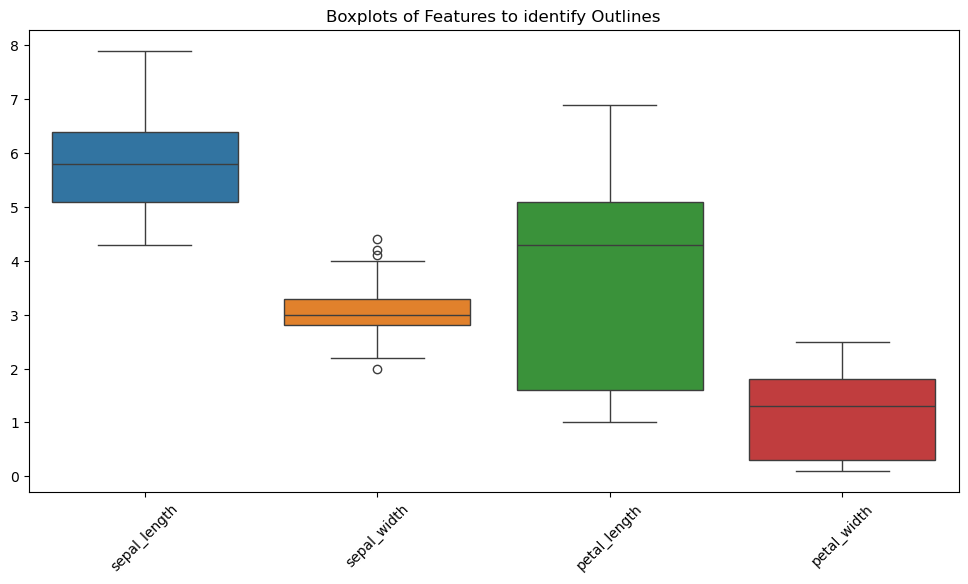

In [26]:
# Boxplot for outlier detection
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Boxplots of Features to identify Outlines")
plt.show()

<b> Inferences from Boxplots: <b>

1. **Sepal Length**:
- There are a few outliers in the sepal length distribution.
- The median sepal length is around 5.8 cm,with theinterquatile range (IQR) between 5.1 and 6.4cm

2. **Sepal Width**:
- There are several outliers in the sepal width distribution.
- the median sepal width is around 3.0 cm, width the (IQR) between 2.8 and 3.3 cm.

3. **petal length**:
- the petal length distribution shows clear separation between species,with minimal overlap
- the median petal length varies significantly between species,indicating it is a good feature for classfication

4. **petal width**:
- Similer to petal length,the petal with distribution shows clear separation between species
- the median petal width varies significatly between species,indicating it is also a good feature for classfication


In [28]:
num_col = df.select_dtypes(include=[np.number]).columns
cat_col =df.select_dtypes(include=['object']).columns
print(f"numerical_data{num_col}")
print(f"categorical_data{cat_col}")

numerical_dataIndex(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')
categorical_dataIndex(['species'], dtype='object')


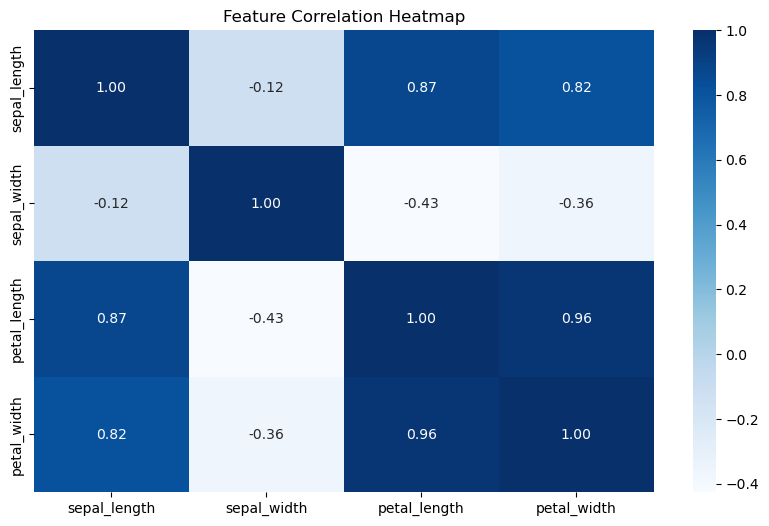

In [37]:
#Correlation Matrix
num = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,6))
corr_matrix = df[num].corr('pearson')
sns.heatmap(corr_matrix,annot=True,cmap="Blues",fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

#### <b> based on the heatmap of the correlation matrix,we can infer the following <b>

1. **sepal length**:
- positively correlated with petal length (0.87) and petal width(0.82).
- weak negative correlation with sepal width(-0.12).

2. **sepal width**:
- weak negative correlation with sepal length (-0.12),petal length(-0.43),and petal width(-0.37).

3. **petal length**:
- strong positive correlation with sepal length (-0.12),and petal width (0.96).
- weak negative correlation with sepal width(-0.43).

4. **petal width**:
- strong positive correlation with petal length(0.96)and sepal length(0.82).
- weak negative correlation with sepal width(-0.37)

5. **species**:
- strong positive correlation with petal length(0.95)and petal width(0.96).
- moderate positive correlation with sepal length(0.78).
- moderate negative correlation with sepal width(-0.43).
  

In [39]:
df.species.value_counts()

species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

In [41]:
# encode target labels
label_encoder = LabelEncoder()
df["species"] = label_encoder.fit_transform(df["species"])

In [43]:
# define feature and target
x =df.drop(columns=["species"]) # all feature except species
y =df["species"] # target frature

In [44]:
# split  into training and testing sets
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [59]:
# function to evaluate k-NN for di
def evaluate_knn(k_values, weights='unifrom'):
    results ={}
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k,weights=weights)

        knn.fit (x_train,y_train)
        y_pred = knn.predict(x_test)
        accuracy = accuracy_score(y_test,y_pred)
        f1 = f1_score(y_test,y_pred,average='weighted')
        results[k]= {'accuracy':accuracy,'f1_score':f1}
    return results

In [60]:
# test for k = 3,5,7
k_values1 =[3,5,7]
regular_knn_results=evaluate_knn(k_values1,weights='uniform')
weighted_knn_results=evaluate_knn(k_values1,weights='distance')

In [62]:
# convert results to dataframe for comparison
results_df = pd.DataFrame.from_dict({
    'Regular k-NN': regular_knn_results,
    'weighted k-NN':weighted_knn_results},orient='index').T
results_df
    
    

,Regular k-NN,weighted k-NN
3,"{'accuracy': 1.0, 'f1_score': 1.0}","{'accuracy': 1.0, 'f1_score': 1.0}"
5,"{'accuracy': 1.0, 'f1_score': 1.0}","{'accuracy': 1.0, 'f1_score': 1.0}"
7,"{'accuracy': 1.0, 'f1_score': 1.0}","{'accuracy': 1.0, 'f1_score': 1.0}"
